In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### t-SNE: t-Distributed Stochastic Neighbor Embedding

**t-SNE** is specifically designed for **visualizing high-dimensional data** in 2D or 3D.

Unlike **PCA** (which preserves **global** structure), **t-SNE preserves local structure** — points that are close in high-dimensional space stay close in the visualization.


#### PCA vs t-SNE

| Feature | PCA | t-SNE |
|---------|-----|-------|
| **Purpose** | Dimensionality reduction | **Visualization** |
| **Preserves** | Global structure (variance) | **Local structure** (neighborhoods) |
| **Output** | Can be used for modeling | **Only for visualization** |
| **Speed** | Fast | Slow |
| **Deterministic** | ✅ Yes | ❌ No (random initialization) |

✅ Use t-SNE for:  Data exploration, clustering visualization
❌ Avoid t-SNE for: Modeling, feature extraction, interpretability

**PCA:** *"Preserve global variance"* (linear)

**t-SNE:** *"Preserve local neighborhoods"* (non-linear)


#### Distance Preservation

| Method | High-D → 2D Relationship |
|--------|--------------------------|
| **PCA** | Points far apart in high-D → **Far apart** in 2D |
| **t-SNE** | Points close in high-D → **Stay close** in 2D<br>Points far in high-D → May or may not be far in 2D |



#### Perplexity

**Perplexity** is the most important parameter in t-SNE. It controls the **balance** between local and global aspects of your data.

> **Perplexity = How many neighbors each point considers when being embedded.**

It's like asking: *"How many nearby points should I pay attention to when deciding where to place this point?"*

#### Perplexity Guidelines

| Perplexity Value | Effect | When to Use |
|------------------|--------|-------------|
| **5-10** | Many small clusters | Small datasets (< 100 points) |
| **10-30** | Good balance | Most datasets |
| **30-50** | Smoother clusters | Medium datasets (100-1000 points) |
| **50-100** | Coarser clusters | Large datasets (> 1000 points) |


#### Rule of Thumb

> **Perplexity should be smaller than the number of data points.**

Usually between **5 and 50**.

**Typical default:** 30


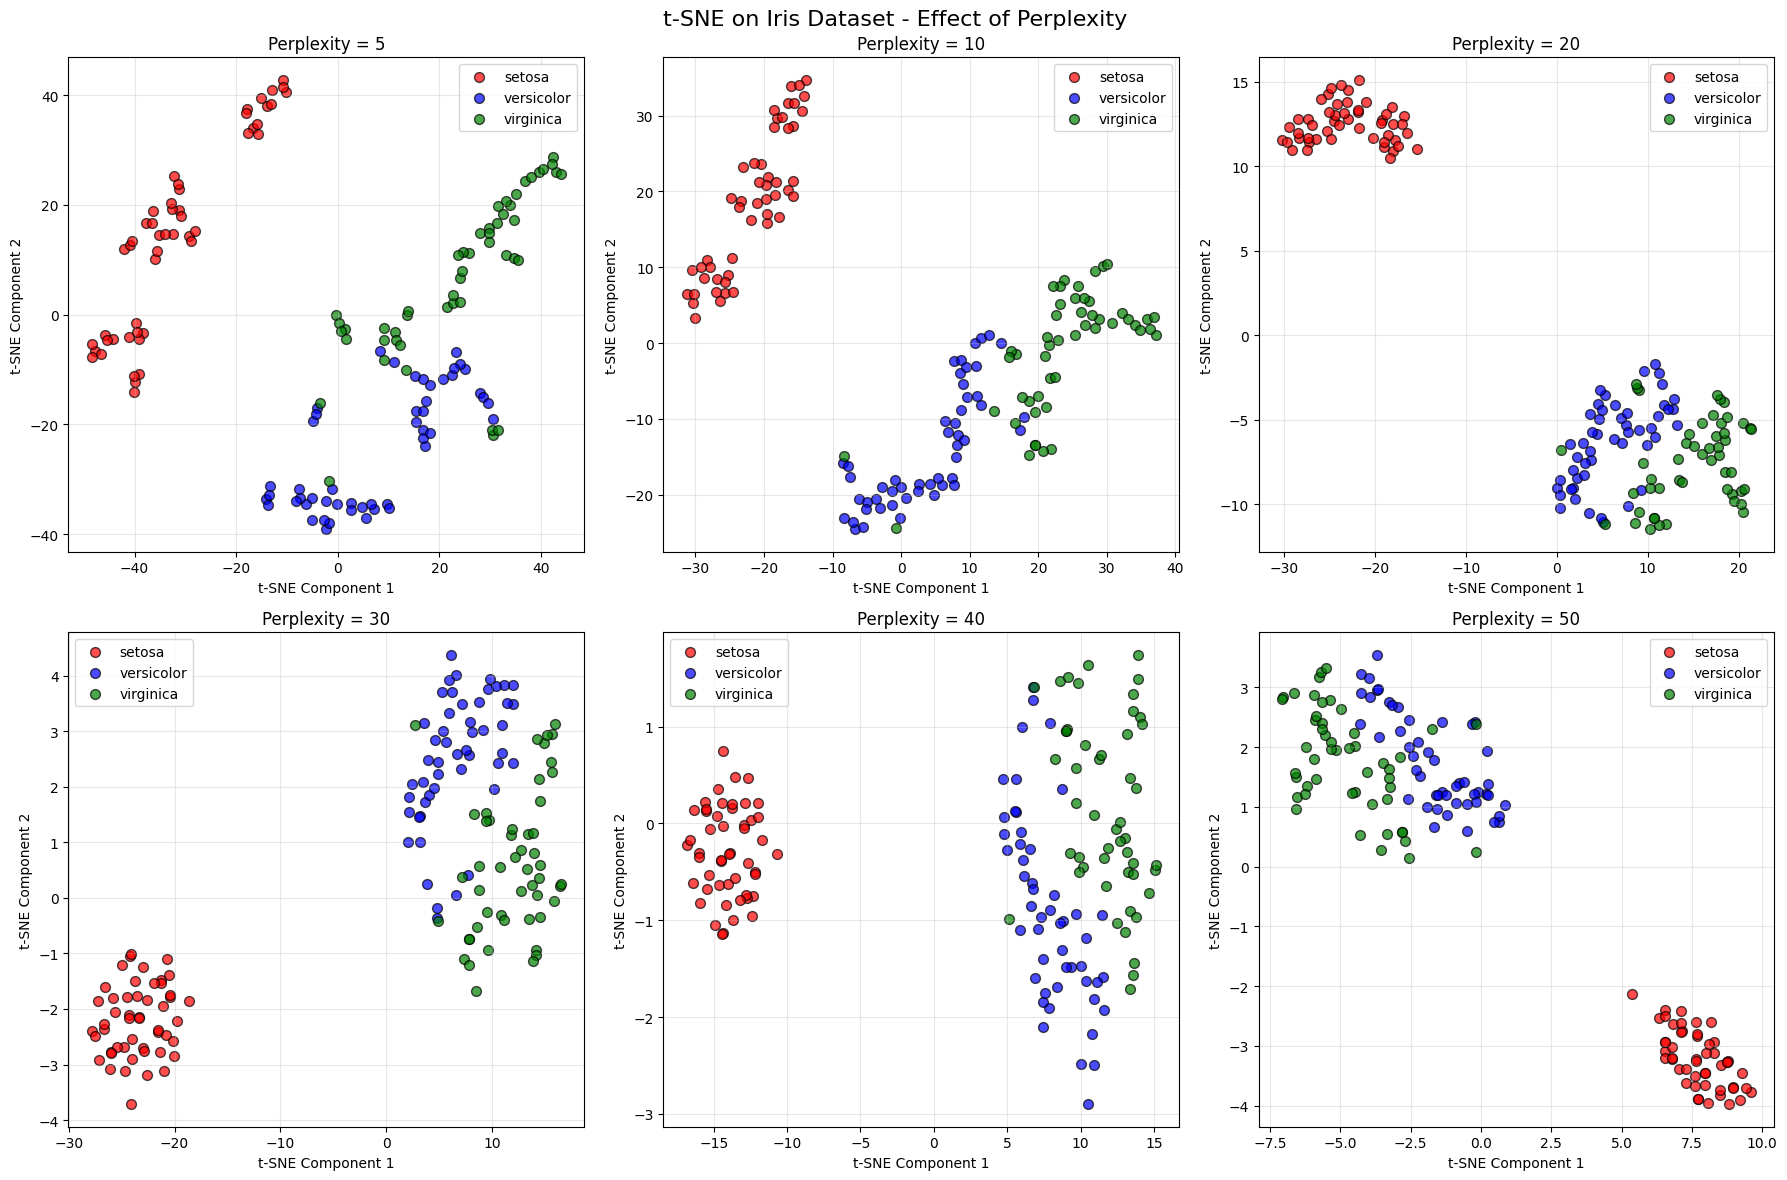

In [4]:
# data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fining optimal perplexity
perplexities = [5, 10, 20, 30, 40, 50]
results = []

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, perplexity in enumerate(perplexities):
    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Plot
    ax = axes[idx]
    colors = ['red', 'blue', 'green']
    for i, species in enumerate(target_names):
        mask = y == i
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[i], label=species, s=50, alpha=0.7, edgecolors='black')
    ax.set_title(f'Perplexity = {perplexity}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('t-SNE on Iris Dataset - Effect of Perplexity', fontsize=16)
plt.tight_layout()
plt.show()

# model
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

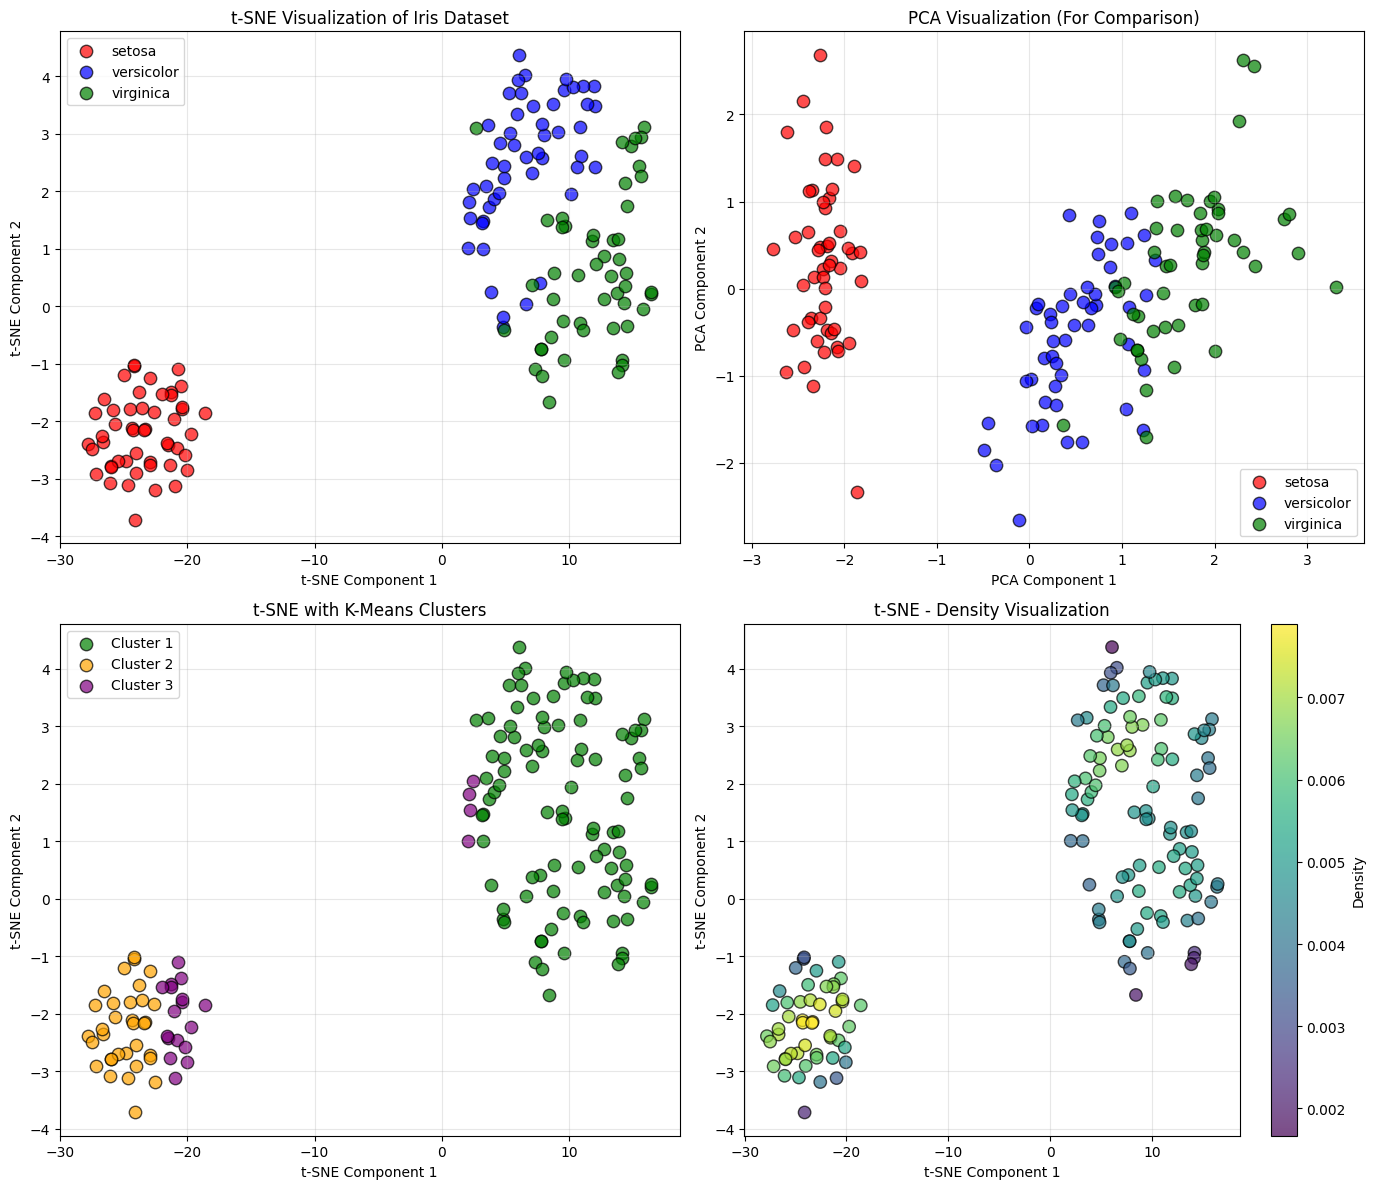

In [6]:
# Create DataFrame with t-SNE results
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['species'] = y
df_tsne['species_name'] = df_tsne['species'].map({i: name for i, name in enumerate(target_names)})

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: t-SNE
ax = axes[0, 0]
colors = ['red', 'blue', 'green']
for i, species in enumerate(target_names):
    mask = y == i
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[i], label=species, s=80, alpha=0.7, edgecolors='black')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('t-SNE Visualization of Iris Dataset')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: PCA for comparison
ax = axes[0, 1]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
for i, species in enumerate(target_names):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], label=species, s=80, alpha=0.7, edgecolors='black')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('PCA Visualization (For Comparison)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: t-SNE with cluster labels
ax = axes[1, 0]
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
y_cluster = kmeans.fit_predict(X_scaled)

colors_clusters = ['green', 'orange', 'purple']
for i in range(3):
    mask = y_cluster == i
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors_clusters[i], label=f'Cluster {i+1}', s=80, alpha=0.7, edgecolors='black')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('t-SNE with K-Means Clusters')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Density visualization
ax = axes[1, 1]
from scipy.stats import gaussian_kde
kde = gaussian_kde(X_tsne.T)
density = kde(X_tsne.T)
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=density, cmap='viridis', s=80, alpha=0.7, edgecolors='black')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('t-SNE - Density Visualization')
plt.colorbar(scatter, ax=ax, label='Density')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()